In [44]:
#读取数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"D:\HuaweiMoveData\Users\魏紫怡\Desktop\KAG_conversion_data.csv")
df.head(20)

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1
5,708820,916,103929,30-34,M,29,1915,0,0.00,1,1
6,708889,916,103940,30-34,M,15,15615,3,4.77,1,0
7,708895,916,103941,30-34,M,16,10951,1,1.27,1,1
8,708953,916,103951,30-34,M,27,2355,1,1.50,1,0
9,708958,916,103952,30-34,M,28,9502,3,3.16,1,0


# 数据清洗

# 缺失值

In [45]:
#判断缺失值，读取字段类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB


# 更变字段类型

In [46]:
# 转分类变量
df[['xyz_campaign_id','age', 'gender', 'interest']] = df[[ 'xyz_campaign_id','age', 'gender', 'interest']].astype('category')
#转字符串
df[['ad_id', 'fb_campaign_id']] = df[['ad_id', 'fb_campaign_id']].astype('str')
#不变
#df[['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']] = df[['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']].apply(pd.to_numeric)

print(df.dtypes)

ad_id                    object
xyz_campaign_id        category
fb_campaign_id           object
age                    category
gender                 category
interest               category
Impressions               int64
Clicks                    int64
Spent                   float64
Total_Conversion          int64
Approved_Conversion       int64
dtype: object


# 判断重复值

In [47]:
df.nunique()

ad_id                  1143
xyz_campaign_id           3
fb_campaign_id          691
age                       4
gender                    2
interest                 40
Impressions            1130
Clicks                  183
Spent                   869
Total_Conversion         32
Approved_Conversion      16
dtype: int64

In [48]:
#数据完全一摸一样的
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


In [51]:
#删除除ad_id外所有相同的列
df=df.drop_duplicates(subset=['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest', 'Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion'], keep="first")
df

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.430000,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.820000,2,0
2,708771,916,103920,30-34,M,20,693,0,0.000000,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,1178,179977,45-49,F,109,1129773,252,358.189997,13,2
1139,1314411,1178,179978,45-49,F,110,637549,120,173.880003,3,0
1140,1314412,1178,179979,45-49,F,111,151531,28,40.289999,2,0
1141,1314414,1178,179981,45-49,F,113,790253,135,198.710000,8,2


In [31]:
dup = df[df.duplicated(subset=['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest'], keep=False)]

# 按五列排序方便查看
dup = dup.sort_values(['xyz_campaign_id', 'fb_campaign_id', 'age', 'gender', 'interest'])
display(dup)

#print(dup.to_string(index=False))

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
3,708815,916,103928,30-34,M,28,4259,1,1.250000,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.290000,1,1
12,709038,916,103965,30-34,M,16,5117,0,0.000000,1,0
13,709040,916,103965,30-34,M,16,5120,0,0.000000,1,0
20,709320,916,104012,35-39,M,15,1422,0,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1042,1122308,1178,144741,45-49,F,63,427772,117,159.299999,3,1
1043,1122310,1178,144742,45-49,F,64,536457,136,193.659999,2,1
1044,1122311,1178,144742,45-49,F,64,179894,43,66.839999,2,0
1045,1122312,1178,144742,45-49,F,64,479882,131,178.670001,6,0


# 判断异常值

In [11]:
#描述性统计
df.describe()

,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,3.052003e+06,421.000000,639.949998,60.000000,21.000000


In [58]:
#判断浏览数小于点击数
result1=df[df['Impressions']<df['Clicks']]
result1

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion


In [61]:
#判断点击数小于转化数
result2=df[df['Clicks']<df['Total_Conversion']]
result2
#存在浏览归因

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
5,708820,916,103929,30-34,M,29,1915,0,0.00,1,1
10,708979,916,103955,30-34,M,31,1224,0,0.00,1,0
11,709023,916,103962,30-34,M,7,735,0,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
851,1121791,1178,144655,30-34,F,23,6838,0,0.00,1,0
880,1121846,1178,144664,30-34,F,32,8350,0,0.00,1,0
882,1121854,1178,144666,30-34,F,63,8587,0,0.00,1,0
894,1121873,1178,144669,30-34,F,2,5264,0,0.00,1,0


In [64]:
click_attribution = df[df['Clicks'] >= df['Total_Conversion']]
view_attribution = df[df['Clicks'] < df['Total_Conversion']]

print(f"点击归因: {len(click_attribution)} 条")
print(f"浏览归因: {len(view_attribution)} 条")
print(f"浏览归因占比: {len(view_attribution)/len(df)*100:.1f}%")

# 浏览归因中，有多少是0点击的？
zero_click = view_attribution[view_attribution['Clicks'] == 0]
print(f"其中0点击有转化: {len(zero_click)} 条")

点击归因: 925 条
浏览归因: 217 条
浏览归因占比: 19.0%
其中0点击有转化: 203 条


In [63]:
#判断转化数小于有效转化数
result3=df[df['Total_Conversion']<df['Approved_Conversion']]
result3

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion


In [65]:
#四分位法
num_cols = ['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, 异常值={len(outliers)}条 ({len(outliers)/len(df)*100:.2f}%)")

Impressions: Q1=6545.25, Q3=221806.0, IQR=215260.75, 异常值=123条 (10.77%)
Clicks: Q1=1.0, Q3=37.75, IQR=36.75, 异常值=127条 (11.12%)
Spent: Q1=1.4800000265, Q3=60.112499742500006, IQR=58.632499716000005, 异常值=125条 (10.95%)
Total_Conversion: Q1=1.0, Q3=3.0, IQR=2.0, 异常值=105条 (9.19%)
Approved_Conversion: Q1=0.0, Q3=1.0, IQR=1.0, 异常值=95条 (8.32%)


D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0, flags=flags)
D:\Users\wzy\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0, flags=flags)


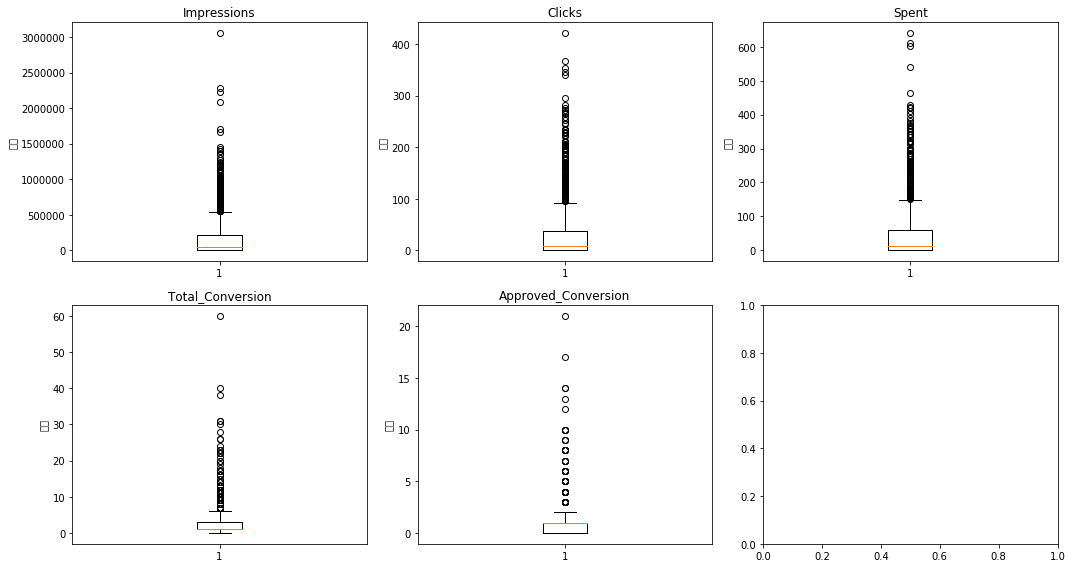

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('数值')

plt.tight_layout()
plt.show()

In [70]:
#运用Z-score检测异常值
from scipy import stats
num_cols = ['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']
for col in num_cols:
    z = stats.zscore(df[col])
    outliers = df[abs(z) > 3]
    print(f"{col}: 异常值 {len(outliers)} 条 ({len(outliers)/len(df)*100:.2f}%)")

Impressions: 异常值 23 条 (2.01%)
Clicks: 异常值 33 条 (2.89%)
Spent: 异常值 32 条 (2.80%)
Total_Conversion: 异常值 26 条 (2.28%)
Approved_Conversion: 异常值 22 条 (1.93%)


# 业务分析

# 整体效果

In [78]:
#这份数据核心指标
total_impressions = df['Impressions'].sum()
total_clicks = df['Clicks'].sum()
total_conversion = df['Total_Conversion'].sum()
total_approved = df['Approved_Conversion'].sum()
total_spent = df['Spent'].sum()

print(f"整体 CTR: {total_clicks / total_impressions * 100:.4f}%")
print(f"整体 CVR: {total_approved / total_clicks * 100:.2f}%")
print(f"整体 CPA: ${total_spent / total_approved:.2f}")
print(f"总曝光: {total_impressions:,}")
print(f"总点击: {total_clicks:,}")
print(f"总转化: {total_conversion:,}")
print(f"总有效转化: {total_approved:,}")
print(f"总支出: {total_spent:.2f}")

整体 CTR: 0.0179%
整体 CVR: 2.82%
整体 CPA: $54.46
总曝光: 213,434,676
总点击: 38,165
总转化: 3,263
总有效转化: 1,078
总支出: 58705.23


In [91]:
# 从活动维度分析
campaign = df.groupby('xyz_campaign_id').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion','sum'),
    购买=('Approved_Conversion', 'sum'),
)

campaign['CTR'] = campaign['点击'] / campaign['曝光'] * 100
campaign['CVR'] = campaign['购买'] / campaign['点击'] * 100
campaign['CPA'] = campaign['花费'] / campaign['购买']
display(campaign)


,花费,曝光,点击,下单,购买,CTR,CVR,CPA
xyz_campaign_id,,,,,,,,
916,149.710001,482925,113,58,24,0.023399,21.238938,6.237917
936,2893.369999,8128035,1984,536,182,0.024409,9.173387,15.897637
1178,55662.149959,204823716,36068,2669,872,0.017609,2.417656,63.832741


In [92]:
#从年龄维度分析
age = df.groupby('age').agg(
    花费=('Spent', 'sum'),
    曝光=('Impressions', 'sum'),
    点击=('Clicks', 'sum'),
    下单=('Total_Conversion','sum'),
    购买=('Approved_Conversion', 'sum')
)
age['CTR'] = age['点击'] / age['曝光'] * 100
age['CVR'] = age['购买'] / age['点击'] * 100
age['CPA'] = age['花费'] / age['购买']
display(age)

,花费,曝光,点击,下单,购买,CTR,CVR,CPA
age,,,,,,,,
30-34,15252.399986,67992867,9483,1430,493,0.013947,5.198777,30.937931
35-39,11112.429994,42104644,7094,626,207,0.016848,2.917959,53.683237
40-44,11589.729981,39604307,7736,523,170,0.019533,2.197518,68.174882
45-49,20750.669997,63732858,13852,684,208,0.021734,1.501588,99.762837


In [93]:
#从性别维度分析
gender=df.groupby('gender').agg(
    花费=('Spent','sum'),
    曝光=('Impressions','sum'),
    点击=('Clicks','sum'),
    下单=('Total_Conversion','sum'),
    购买=('Approved_Conversion','sum')
)
gender['CTR'] = gender['点击'] / gender['曝光'] * 100
gender['CVR'] = gender['购买'] / gender['点击'] * 100
gender['CPA'] = gender['花费'] / gender['购买']
display(gender)

,花费,曝光,点击,下单,购买,CTR,CVR,CPA
gender,,,,,,,,
F,34502.619963,114862847,23878,1644,495,0.020788,2.073038,69.702263
M,24202.609995,98571829,14287,1619,583,0.014494,4.080633,41.513911


In [105]:
#从兴趣维度分析
interest=df.groupby('interest').agg(
    花费=('Spent','sum'),
    曝光=('Impressions','sum'),
    点击=('Clicks','sum'),
    下单=('Total_Conversion','sum'),
    购买=('Approved_Conversion','sum')
)
interest['CTR'] = interest['点击'] / interest['曝光'] * 100
interest['CVR'] = interest['购买'] / interest['点击'] * 100
interest['CPA'] = interest['花费'] / interest['购买']
interest=interest.sort_values(['购买','花费'],ascending=[False,True])
display(interest)

,花费,曝光,点击,下单,购买,CTR,CVR,CPA
interest,,,,,,,,
16,8084.909990,31809524,5144,411,141,0.016171,2.741058,57.339787
29,5045.190008,18768653,3315,306,132,0.017662,3.981900,38.221136
10,5086.379995,17989844,3317,269,91,0.018438,2.743443,55.894286
15,2597.259995,10745856,1609,195,63,0.014973,3.915475,41.226349
27,5176.169992,16352527,3409,240,54,0.020847,1.584042,95.855000
20,1960.770001,6899907,1234,129,47,0.017884,3.808752,41.718511
28,3205.850004,10959830,2025,146,42,0.018477,2.074074,76.329762
32,1970.530003,6455261,1138,76,35,0.017629,3.075571,56.300857
63,2484.060002,8365640,1675,101,34,0.020022,2.029851,73.060588


In [106]:
zombie = df[(df['Spent'] > 0) & (df['Approved_Conversion'] == 0)]
print(f"僵尸广告: {len(zombie)} 个，浪费 ${zombie['Spent'].sum():.2f}")
print(zombie.groupby('xyz_campaign_id')['Spent'].sum())

僵尸广告: 423 个，浪费 $14754.42
xyz_campaign_id
916        74.310001
936      1910.420000
1178    12769.690008
Name: Spent, dtype: float64


In [107]:
best = df[df['Approved_Conversion'] > 0].groupby(
    ['xyz_campaign_id', 'age', 'gender', 'interest']
).agg(购买=('Approved_Conversion', 'sum'), 花费=('Spent', 'sum'))
best['CPA'] = best['花费'] / best['购买']
best = best.sort_values('CPA')
print(best.head(10))

                                        购买   花费  CPA
xyz_campaign_id age   gender interest               
936             45-49 M      29        1.0  0.0  0.0
                30-34 M      18        1.0  0.0  0.0
                             21        2.0  0.0  0.0
                35-39 F      32        1.0  0.0  0.0
                40-44 F      2         1.0  0.0  0.0
                30-34 F      26        2.0  0.0  0.0
                      M      30        1.0  0.0  0.0
                      F      21        1.0  0.0  0.0
                      M      32        2.0  0.0  0.0
                45-49 M      21        1.0  0.0  0.0


In [78]:
duplicate_count=df.duplicated().sum()
print(f"重复行数量: {duplicate_count}")

重复行数量: 0


In [79]:
numeric_cols = ['Impressions', 'Clicks', 'Spent', 'Total_Conversion', 'Approved_Conversion']
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"⚠️ {col} 有 {negative_count} 条负值记录")
    else:
        print(f"✅ {col} 没有负值")

✅ Impressions 没有负值
✅ Clicks 没有负值
✅ Spent 没有负值
✅ Total_Conversion 没有负值
✅ Approved_Conversion 没有负值


In [80]:
invalid_click=(df['Impressions']<df['Clicks']).sum()
print(f"点击大于展示的异常记录数:{invalid_click}")

点击大于展示的异常记录数:0


In [81]:
invalid_conversion=(df['Total_Conversion']>df['Clicks']).sum()
print(f"转化大于点击的异常记录数:{invalid_conversion}")

转化大于点击的异常记录数:218


In [82]:
df_invalid_conversion=df[(df['Total_Conversion']>df['Clicks'])]
#df_invalid_conversion['Total_Conversion'].sort_values(ascending=False)
df_invalid_conversion

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
5,708820,916,103929,30-34,M,29,1915,0,0.00,1,1
10,708979,916,103955,30-34,M,31,1224,0,0.00,1,0
11,709023,916,103962,30-34,M,7,735,0,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
851,1121791,1178,144655,30-34,F,23,6838,0,0.00,1,0
880,1121846,1178,144664,30-34,F,32,8350,0,0.00,1,0
882,1121854,1178,144666,30-34,F,63,8587,0,0.00,1,0
894,1121873,1178,144669,30-34,F,2,5264,0,0.00,1,0


In [83]:
df_invalid_conversion['xyz_campaign_id'].value_counts()

936     180
916      21
1178     17
Name: xyz_campaign_id, dtype: int64

In [99]:
invalid_Approved_Conversion=(df['Approved_Conversion']>df['Clicks']).sum()
print(f"支付大于点击的异常值:{invalid_Approved_Conversion}")

支付大于点击的异常值:72


In [100]:
total_rows = len(df)
invalid_conversion/total_rows

0.19072615923009623

In [101]:
df_invalid_Approved_Conversion=df[df['Approved_Conversion']>df['Clicks']]
df_invalid_Approved_Conversion

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
5,708820,916,103929,30-34,M,29,1915,0,0.0,1,1
15,709105,916,103976,30-34,M,28,1241,0,0.0,1,1
17,709124,916,103979,30-34,M,31,1024,0,0.0,1,1
20,709320,916,104012,35-39,M,15,1422,0,0.0,1,1
24,709328,916,104013,35-39,M,16,3332,0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
500,951641,936,123700,40-44,F,2,87,0,0.0,1,1
517,952100,936,123777,35-39,F,29,810,0,0.0,1,1
520,1121094,1178,144531,30-34,M,10,24362,0,0.0,1,1
599,1121252,1178,144565,30-34,M,63,11139,0,0.0,1,1


In [102]:
column_mapping = {
    'ad_id': '广告ID',
    'xyz_campaign_id': '公司活动ID',
    'fb_campaign_id': 'Facebook活动ID',
    'age': '年龄',
    'gender': '性别',
    'interest': '兴趣代码',
    'Impressions': '展示次数',
    'Clicks': '点击次数',
    'Spent': '广告花费',
    'Total_Conversion': '总转化数',
    'Approved_Conversion': '获批转化数'
}

df = df.rename(columns=column_mapping)
df.head()

,广告ID,公司活动ID,Facebook活动ID,年龄,性别,兴趣代码,展示次数,点击次数,广告花费,总转化数,获批转化数
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [106]:
group_stats = df.groupby(['公司活动ID', '年龄', '性别', '兴趣代码']).agg({
    '总转化数': ['count', 'mean', 'std'],
    '点击次数': 'mean'
}).round(2)

print("分组统计（前20行预览）:")
print(group_stats.head(20))

print(f"\n总分组数: {len(group_stats)}")

分组统计（前20行预览）:
                      总转化数              点击次数
                     count  mean   std  mean
公司活动ID 年龄    性别 兴趣代码                        
916    30-34 F  15       2  1.00  0.00  1.00
                16       3  1.00  0.00  7.00
                18       1  1.00   NaN  0.00
                27       1  1.00   NaN  0.00
                29       1  1.00   NaN  7.00
                32       1  1.00   NaN  1.00
                63       1  1.00   NaN  0.00
                65       1  1.00   NaN  5.00
             M  7        1  1.00   NaN  0.00
                15       2  1.50  0.71  2.00
                16       4  1.25  0.50  0.75
                20       2  1.00  0.00  3.50
                27       1  1.00   NaN  1.00
                28       4  1.00  0.00  1.25
                29       1  1.00   NaN  0.00
                30       1  1.00   NaN  1.00
                31       2  1.00  0.00  0.00
       35-39 F  20       1  1.00   NaN  1.00
                25       1  1.00   NaN  1

In [104]:
sample_counts = df.groupby(['公司活动ID', '年龄', '性别', '兴趣代码']).size()
print("\n每组样本量分布:")
print(sample_counts.describe())


每组样本量分布:
count    454.000000
mean       2.517621
std        2.071226
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       16.000000
dtype: float64


In [107]:
print("\n" + "="*60)
print("【按样本量分组处理】")
print("="*60)

# 定义阈值：样本量>=5的组用均值替换，样本量<5的组用全局均值或压平处理
min_sample_threshold = 5

# 计算每组的平均总转化数
group_means = df.groupby(['公司活动ID', '年龄', '性别', '兴趣代码'])['总转化数'].mean()

# 计算每组的样本量
group_counts = df.groupby(['公司活动ID', '年龄', '性别', '兴趣代码']).size()

# 标记哪些组样本量充足
large_groups = group_counts[group_counts >= min_sample_threshold].index.tolist()
small_groups = group_counts[group_counts < min_sample_threshold].index.tolist()

print(f"样本量 >= {min_sample_threshold} 的组: {len(large_groups)} 个")
print(f"样本量 < {min_sample_threshold} 的组: {len(small_groups)} 个")


【按样本量分组处理】
样本量 >= 5 的组: 64 个
样本量 < 5 的组: 390 个


In [108]:
print("="*60)
print("【方案A：按3维度分组（年龄+性别+兴趣）】")
print("="*60)

# 按3个维度分组
group_stats_3d = df.groupby(['年龄', '性别', '兴趣代码']).agg({
    '总转化数': ['count', 'mean'],
    '点击次数': 'mean'
}).round(2)

group_counts_3d = df.groupby(['年龄', '性别', '兴趣代码']).size()
large_3d = (group_counts_3d >= 5).sum()
small_3d = (group_counts_3d < 5).sum()
total_3d = len(group_counts_3d)

print(f"总分组数: {total_3d}")
print(f"样本量 >= 5 的组: {large_3d} 个 ({large_3d/total_3d*100:.1f}%)")
print(f"样本量 < 5 的组: {small_3d} 个 ({small_3d/total_3d*100:.1f}%)")
print(f"每组平均样本量: {group_counts_3d.mean():.1f} 条")

【方案A：按3维度分组（年龄+性别+兴趣）】
总分组数: 284
样本量 >= 5 的组: 94 个 (33.1%)
样本量 < 5 的组: 190 个 (66.9%)
每组平均样本量: 4.0 条


In [110]:
import pandas as pd

print("="*60)
print("【兴趣代码异常详情（含总数量）】")
print("="*60)

total_abnormal = (df['总转化数'] > df['点击次数']).sum()
print(f"总异常数: {total_abnormal} 条\n")

# 兴趣代码分析：总数量、异常数量、异常率、贡献度
interest_abnormal = df[df['总转化数'] > df['点击次数']]['兴趣代码'].value_counts()
interest_total = df['兴趣代码'].value_counts()

# 合并成一张表
interest_summary = pd.DataFrame({
    '总数量': interest_total,
    '异常数量': interest_abnormal,
    '异常率(%)': (interest_abnormal / interest_total * 100).round(2),
    '占总异常比例(%)': (interest_abnormal / total_abnormal * 100).round(2)
}).fillna(0).sort_values('异常数量', ascending=False)

print("【兴趣代码完整统计】")
print("="*70)
print(interest_summary)
print("="*70)

【兴趣代码异常详情（含总数量）】
总异常数: 218 条

【兴趣代码完整统计】
     总数量  异常数量  异常率(%)  占总异常比例(%)
16   140  27.0   19.29      12.39
29    77  17.0   22.08       7.80
10    85  16.0   18.82       7.34
15    51  16.0   31.37       7.34
64    48  12.0   25.00       5.50
26    41  12.0   29.27       5.50
21    36  11.0   30.56       5.05
20    49   9.0   18.37       4.13
63    46   9.0   19.57       4.13
32    33   9.0   27.27       4.13
18    43   9.0   20.93       4.13
28    51   9.0   17.65       4.13
31    25   8.0   32.00       3.67
27    60   8.0   13.33       3.67
7     24   7.0   29.17       3.21
30    25   6.0   24.00       2.75
2     25   6.0   24.00       2.75
36    21   5.0   23.81       2.29
23    23   5.0   21.74       2.29
19    32   5.0   15.62       2.29
65    19   4.0   21.05       1.83
25    26   2.0    7.69       0.92
22    33   2.0    6.06       0.92
24    24   2.0    8.33       0.92
66    11   1.0    9.09       0.46
112    7   1.0   14.29       0.46
107    8   0.0    0.00       0.00
113    

In [112]:
print("\n【异常率 TOP 10（内部数据质量最差）】")
print("="*70)
print(interest_summary[['总数量', '异常数量', '异常率(%)', '占总异常比例(%)']].sort_values('异常率(%)', ascending=False).head(10))


【异常率 TOP 10（内部数据质量最差）】
    总数量  异常数量  异常率(%)  占总异常比例(%)
31   25   8.0   32.00       3.67
15   51  16.0   31.37       7.34
21   36  11.0   30.56       5.05
26   41  12.0   29.27       5.50
7    24   7.0   29.17       3.21
32   33   9.0   27.27       4.13
64   48  12.0   25.00       5.50
30   25   6.0   24.00       2.75
2    25   6.0   24.00       2.75
36   21   5.0   23.81       2.29


In [113]:
for campaign in df['公司活动ID'].unique():
    total = len(df[df['公司活动ID'] == campaign])
    abnormal = (df[df['公司活动ID'] == campaign]['总转化数'] > df[df['公司活动ID'] == campaign]['点击次数']).sum()
    pct = abnormal / total * 100
    print(f"活动 {campaign}: 总数据 {total} 条，异常 {abnormal} 条 ({pct:.1f}%)")

活动 916: 总数据 54 条，异常 21 条 (38.9%)
活动 936: 总数据 464 条，异常 180 条 (38.8%)
活动 1178: 总数据 625 条，异常 17 条 (2.7%)


In [114]:
print("="*70)
print("【按活动+年龄+性别+兴趣 的异常占比详情】")
print("="*70)

# 按四个维度分组，统计每组的总数和异常数
grouped = df.groupby(['公司活动ID', '年龄', '性别', '兴趣代码']).agg(
    总数=('总转化数', 'count'),
    异常数=('总转化数', lambda x: (x > df.loc[x.index, '点击次数']).sum())
).reset_index()

# 计算异常占比
grouped['异常占比(%)'] = (grouped['异常数'] / grouped['总数'] * 100).round(2)

# 按异常占比排序
grouped_sorted = grouped.sort_values('异常占比(%)', ascending=False)

print("异常占比 TOP 30 的组合：")
print("="*70)
print(grouped_sorted.head(30).to_string(index=False))

【按活动+年龄+性别+兴趣 的异常占比详情】
异常占比 TOP 30 的组合：
 公司活动ID     年龄 性别  兴趣代码  总数  异常数  异常占比(%)
    936  30-34  M    63   2    2    100.0
    916  40-44  F    15   1    1    100.0
    936  30-34  F    65   1    1    100.0
    916  45-49  F    19   1    1    100.0
    936  40-44  M    15   1    1    100.0
    936  40-44  M     7   1    1    100.0
    936  30-34  M    25   1    1    100.0
    936  30-34  F     2   1    1    100.0
    936  40-44  F    30   1    1    100.0
    936  40-44  F    29   1    1    100.0
    936  40-44  F    21   2    2    100.0
    936  40-44  F     7   1    1    100.0
    936  40-44  F     2   1    1    100.0
    936  35-39  M    32   1    1    100.0
    936  30-34  M    21   3    3    100.0
    936  30-34  F    24   1    1    100.0
    936  35-39  F    18   1    1    100.0
    936  30-34  M    19   1    1    100.0
    936  35-39  M    26   1    1    100.0
    936  35-39  M    23   1    1    100.0
    936  35-39  F    23   1    1    100.0
    936  30-34  F    30   2    2    

In [115]:
print("\n" + "="*70)
print("【按活动+年龄 的异常占比】")
print("="*70)

age_campaign = df.groupby(['公司活动ID', '年龄']).agg(
    总数=('总转化数', 'count'),
    异常数=('总转化数', lambda x: (x > df.loc[x.index, '点击次数']).sum())
).reset_index()
age_campaign['异常占比(%)'] = (age_campaign['异常数'] / age_campaign['总数'] * 100).round(2)

print(age_campaign.sort_values(['公司活动ID', '年龄']).to_string(index=False))


【按活动+年龄 的异常占比】
 公司活动ID     年龄   总数  异常数  异常占比(%)
    916  30-34   29   13    44.83
    916  35-39   12    3    25.00
    916  40-44    6    3    50.00
    916  45-49    7    2    28.57
    936  30-34  196  103    52.55
    936  35-39   89   31    34.83
    936  40-44   75   20    26.67
    936  45-49  104   26    25.00
   1178  30-34  201   14     6.97
   1178  35-39  147    2     1.36
   1178  40-44  129    1     0.78
   1178  45-49  148    0     0.00


In [85]:
# 筛选出异常数据（总转化数 > 点击次数）
abnormal_df = df[df['总转化数'] > df['点击次数']].copy()

print("="*60)
print("【异常数据特征分析】")
print("="*60)

print(f"总转化数 > 点击次数的记录数: {len(abnormal_df)} 条")
print(f"占总数据比例: {len(abnormal_df) / len(df) * 100:.2f}%\n")

print("异常数据的统计描述:")
print(abnormal_df[['点击次数', '总转化数', '获批转化数', '展示次数', '广告花费']].describe())

【异常数据特征分析】
总转化数 > 点击次数的记录数: 218 条
占总数据比例: 19.07%

异常数据的统计描述:
             点击次数        总转化数       获批转化数          展示次数        广告花费
count  218.000000  218.000000  218.000000    218.000000  218.000000
mean     0.073394    1.119266    0.385321   3219.440367    0.100917
std      0.294541    0.389370    0.541516   5522.238038    0.431756
min      0.000000    1.000000    0.000000     87.000000    0.000000
25%      0.000000    1.000000    0.000000    744.500000    0.000000
50%      0.000000    1.000000    0.000000   1526.500000    0.000000
75%      0.000000    1.000000    1.000000   3285.750000    0.000000
max      2.000000    4.000000    2.000000  51104.000000    3.240000


In [71]:
# 对比：异常数据 vs 正常数据
print("="*60)
print("【异常数据 vs 正常数据 对比】")
print("="*60)

normal_df = df[df['总转化数'] <= df['点击次数']]

compare = pd.DataFrame({
    '指标': ['展示次数', '点击次数', '总转化数', '获批转化数', '广告花费'],
    '异常数据(均值)': [
        abnormal_df['展示次数'].mean(),
        abnormal_df['点击次数'].mean(),
        abnormal_df['总转化数'].mean(),
        abnormal_df['获批转化数'].mean(),
        abnormal_df['广告花费'].mean()
    ],
    '正常数据(均值)': [
        normal_df['展示次数'].mean(),
        normal_df['点击次数'].mean(),
        normal_df['总转化数'].mean(),
        normal_df['获批转化数'].mean(),
        normal_df['广告花费'].mean()
    ]
})
print(compare)

【异常数据 vs 正常数据 对比】
      指标     异常数据(均值)       正常数据(均值)
0   展示次数  3219.440367  229981.610811
1   点击次数     0.073394      41.242162
2   总转化数     1.119266       3.264865
3  获批转化数     0.385321       1.075676
4   广告花费     0.100917      63.441330


In [86]:
print("="*60)
print("【异常数据在各类别中的分布】")
print("="*60)

# 按年龄看异常占比
age_error_pct = df.groupby('年龄').apply(
    lambda x: (x['总转化数'] > x['点击次数']).sum() / len(x) * 100
)
print("\n各年龄段异常占比:")
print(age_error_pct.sort_values(ascending=False))

# 按性别看异常占比
gender_error_pct = df.groupby('性别').apply(
    lambda x: (x['总转化数'] > x['点击次数']).sum() / len(x) * 100
)
print("\n各性别异常占比:")
print(gender_error_pct)

# 按兴趣代码看异常占比（取前10）
interest_error_pct = df.groupby('兴趣代码').apply(
    lambda x: (x['总转化数'] > x['点击次数']).sum() / len(x) * 100
)
print("\n异常占比最高的10个兴趣代码:")
print(interest_error_pct.sort_values(ascending=False).head(10))

【异常数据在各类别中的分布】

各年龄段异常占比:
年龄
30-34    30.516432
35-39    14.516129
40-44    11.428571
45-49    10.810811
dtype: float64

各性别异常占比:
性别
F    16.152450
M    21.790541
dtype: float64

异常占比最高的10个兴趣代码:
兴趣代码
31    32.000000
15    31.372549
21    30.555556
26    29.268293
7     29.166667
32    27.272727
64    25.000000
30    24.000000
2     24.000000
36    23.809524
dtype: float64


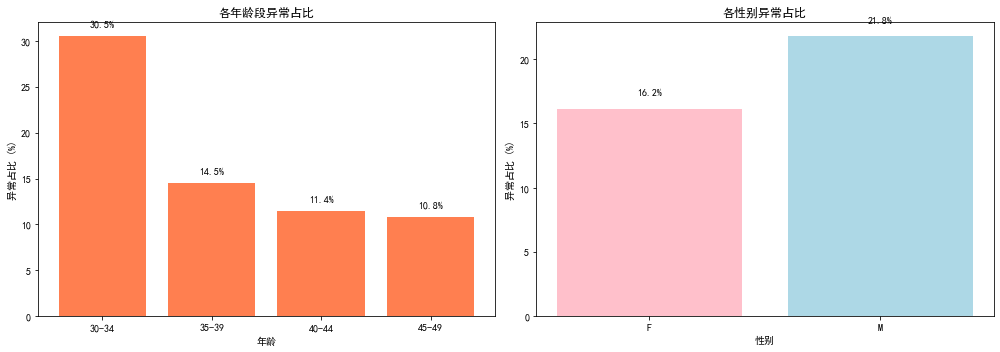

In [73]:
# 可视化：异常数据在各维度的分布
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 各年龄段异常数量
age_abnormal = df.groupby('年龄').apply(
    lambda x: (x['总转化数'] > x['点击次数']).sum()
)
age_total = df.groupby('年龄').size()
age_pct = age_abnormal / age_total * 100

axes[0].bar(age_pct.index, age_pct.values, color='coral')
axes[0].set_title('各年龄段异常占比')
axes[0].set_xlabel('年龄')
axes[0].set_ylabel('异常占比 (%)')
for i, v in enumerate(age_pct.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# 各性别异常数量
gender_abnormal = df.groupby('性别').apply(
    lambda x: (x['总转化数'] > x['点击次数']).sum()
)
gender_total = df.groupby('性别').size()
gender_pct = gender_abnormal / gender_total * 100

axes[1].bar(gender_pct.index, gender_pct.values, color=['pink', 'lightblue'])
axes[1].set_title('各性别异常占比')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('异常占比 (%)')
for i, v in enumerate(gender_pct.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()